# Домашнее задание 3: VaR, ES и копулы

В этом ноутбуке построен полный пайплайн для портфеля из пяти инструментов:

- акции: `NVDA`, `JPM`, `XOM`;
- валюты: `USDJPY`, `GBPUSD`.

Выбор специально не ограничен Google и EUR/USD: акции взяты из разных секторов, валюты дают отдельный FX-блок. Данные берутся за последние 10 лет из Yahoo Finance и кешируются в `hw3_prices.csv` рядом с заданием, чтобы ноутбук был воспроизводимым.


In [1]:
import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from arch import arch_model
from copulae import ClaytonCopula, FrankCopula, GumbelCopula
from scipy import stats
from scipy.stats import chi2

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.options.display.float_format = "{:,.4f}".format

RANDOM_SEED = 322
rng = np.random.default_rng(RANDOM_SEED)


In [2]:
def log_returns(prices):
    return np.log(prices).diff().dropna() * 100


def fit_scipy_margins(data, candidate_dists):
    rows = []
    specs = {}
    for col in data.columns:
        x = data[col].dropna().to_numpy(dtype=float)
        local_rows = []
        for name, dist in candidate_dists.items():
            try:
                params = dist.fit(x)
                loglik = np.sum(dist.logpdf(x, *params))
                aic = 2 * len(params) - 2 * loglik
                local_rows.append(
                    {
                        "instrument": col,
                        "dist": name,
                        "aic": aic,
                        "loglik": loglik,
                        "n_params": len(params),
                        "params": params,
                    }
                )
            except Exception:
                continue
        local_rows = sorted(local_rows, key=lambda row: row["aic"])
        rows.extend(local_rows)
        best = local_rows[0]
        specs[col] = {
            "name": best["dist"],
            "dist": candidate_dists[best["dist"]],
            "params": best["params"],
            "aic": best["aic"],
        }
    return pd.DataFrame(rows), specs


def to_unit_cube(data, specs, eps=1e-6):
    u = pd.DataFrame(index=data.index)
    for col, spec in specs.items():
        u[col] = spec["dist"].cdf(data[col].to_numpy(dtype=float), *spec["params"])
    return u.clip(eps, 1 - eps)


def inverse_margins(u, specs):
    out = pd.DataFrame(index=u.index)
    for col, spec in specs.items():
        out[col] = spec["dist"].ppf(u[col].clip(1e-6, 1 - 1e-6), *spec["params"])
    return out


def frank_logpdf(u, v, theta):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    if abs(theta) < 1e-8:
        return np.zeros_like(u)
    a = np.exp(-theta)
    au = np.exp(-theta * u)
    av = np.exp(-theta * v)
    numerator = -theta * (a - 1) * np.exp(-theta * (u + v))
    denominator = (a - 1 + (au - 1) * (av - 1)) ** 2
    density = np.maximum(numerator / denominator, 1e-300)
    return np.log(density)


def fit_frank_by_tau(u2):
    tau = u2.corr(method="kendall").iloc[0, 1]
    cop = FrankCopula(dim=2)
    theta = 0.0 if abs(tau) < 1e-8 else float(cop.itau(float(tau)))
    cop.params = theta
    ll = float(frank_logpdf(u2.iloc[:, 0], u2.iloc[:, 1], theta).sum())
    return cop, pd.DataFrame(
        [
            {
                "copula": "Frank",
                "theta": theta,
                "kendall_tau": tau,
                "loglik": ll,
                "aic": 2 - 2 * ll,
            }
        ]
    )


def fit_archimedean_stock_copulas(u_stock):
    rows = []
    fitted = {}
    for cls in [ClaytonCopula, FrankCopula, GumbelCopula]:
        cop = cls(dim=u_stock.shape[1])
        cop.fit(u_stock.to_numpy(), method="itau", to_pobs=False, verbose=0)
        ll = float(cop.log_lik(u_stock.to_numpy(), to_pobs=False))
        k = int(np.size(cop.params))
        aic = 2 * k - 2 * ll
        rows.append(
            {
                "copula": cls.__name__.replace("Copula", ""),
                "theta": float(np.asarray(cop.params).reshape(-1)[0]),
                "loglik": ll,
                "aic": aic,
            }
        )
        fitted[cls.__name__.replace("Copula", "")] = cop
    table = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
    return table, fitted[table.loc[0, "copula"]]


def simulate_grouped_copulas(stock_copula, fx_copula, columns, n_sim=100_000, seed=RANDOM_SEED):
    stock_cols = ["NVDA", "JPM", "XOM"]
    fx_cols = ["USDJPY", "GBPUSD"]
    u_sim = pd.DataFrame(index=np.arange(n_sim), columns=columns, dtype=float)
    u_sim.loc[:, stock_cols] = stock_copula.random(n_sim, seed=seed)
    if abs(float(fx_copula.params)) < 1e-8:
        u_sim.loc[:, fx_cols] = np.random.default_rng(seed + 1).random((n_sim, 2))
    else:
        u_sim.loc[:, fx_cols] = fx_copula.random(n_sim, seed=seed + 1)
    return u_sim


def kupiec_test(hits, alpha=0.05):
    hits = np.asarray(hits, dtype=int)
    n = len(hits)
    x = hits.sum()
    phat = x / n
    if x == 0 or x == n:
        lr_uc = np.inf
        pvalue = 0.0
    else:
        lr_uc = -2 * (
            (n - x) * np.log((1 - alpha) / (1 - phat))
            + x * np.log(alpha / phat)
        )
        pvalue = 1 - chi2.cdf(lr_uc, 1)
    return lr_uc, pvalue, phat, int(x)


def christoffersen_independence_test(hits):
    hits = np.asarray(hits, dtype=int)
    n00 = int(np.sum((hits[:-1] == 0) & (hits[1:] == 0)))
    n01 = int(np.sum((hits[:-1] == 0) & (hits[1:] == 1)))
    n10 = int(np.sum((hits[:-1] == 1) & (hits[1:] == 0)))
    n11 = int(np.sum((hits[:-1] == 1) & (hits[1:] == 1)))

    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    pi0 = n01 / max(n00 + n01, 1)
    pi1 = n11 / max(n10 + n11, 1)

    def xlogp(x, p):
        return 0.0 if x == 0 or p <= 0 else x * np.log(p)

    ll_ind = xlogp(n00, 1 - pi0) + xlogp(n01, pi0) + xlogp(n10, 1 - pi1) + xlogp(n11, pi1)
    ll_pool = xlogp(n00 + n10, 1 - pi) + xlogp(n01 + n11, pi)
    lr_ind = -2 * (ll_pool - ll_ind)
    pvalue = 1 - chi2.cdf(lr_ind, 1)
    return lr_ind, pvalue, {"n00": n00, "n01": n01, "n10": n10, "n11": n11}


def backtest_var(returns, var, alpha=0.05):
    aligned = pd.concat([returns.rename("r"), var.rename("VaR")], axis=1).dropna()
    hits = (aligned["r"] < aligned["VaR"]).astype(int)
    lr_uc, p_uc, hit_rate, n_hits = kupiec_test(hits, alpha=alpha)
    lr_ind, p_ind, transitions = christoffersen_independence_test(hits)
    lr_cc = lr_uc + lr_ind
    p_cc = 1 - chi2.cdf(lr_cc, 2)
    return {
        "n_obs": len(hits),
        "n_hits": n_hits,
        "hit_rate": hit_rate,
        "LR_uc": lr_uc,
        "p_uc": p_uc,
        "LR_ind": lr_ind,
        "p_ind": p_ind,
        "LR_cc": lr_cc,
        "p_cc": p_cc,
        **transitions,
    }


## 1. Загрузка данных

In [3]:
BASE_DIR = Path(r"/Users/maria/Desktop/work/HSE/additional/hse_githubs/Time series/2026-spring/homeworks/hw3")
CACHE_PATH = BASE_DIR / "hw3_prices.csv"
LOCAL_CACHE_PATH = Path.cwd() / "hw3_prices.csv"

tickers = {
    "NVDA": "NVDA",
    "JPM": "JPM",
    "XOM": "XOM",
    "USDJPY": "JPY=X",
    "GBPUSD": "GBPUSD=X",
}

if CACHE_PATH.exists():
    prices = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True)
    data_source = str(CACHE_PATH)
elif LOCAL_CACHE_PATH.exists():
    prices = pd.read_csv(LOCAL_CACHE_PATH, index_col=0, parse_dates=True)
    data_source = str(LOCAL_CACHE_PATH)
else:
    end = pd.Timestamp.today().normalize()
    start = end - pd.DateOffset(years=10)
    downloaded = yf.download(
        list(tickers.values()),
        start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        threads=False,
    )
    prices = downloaded["Close"].rename(columns={v: k for k, v in tickers.items()})
    prices = prices[list(tickers.keys())].dropna(how="all").ffill().dropna()
    prices.to_csv(LOCAL_CACHE_PATH)
    data_source = "Yahoo Finance"

returns = log_returns(prices)
weights = pd.Series(1 / len(returns.columns), index=returns.columns, name="weight")
portfolio_returns = returns.dot(weights).rename("portfolio")

display(pd.DataFrame({
    "data_source": [data_source],
    "start": [prices.index.min().date()],
    "end": [prices.index.max().date()],
    "n_prices": [len(prices)],
    "n_returns": [len(returns)],
}))
display(prices.tail())
display(weights.to_frame())


,data_source,start,end,n_prices,n_returns
0,/Users/maria/Desktop/Code/new/hw3_prices.csv,2016-08-01,2026-07-30,2605,2604


,NVDA,JPM,XOM,USDJPY,GBPUSD
Date,,,,,
2026-07-24,206.8400,353.2100,156.9400,163.8320,1.3313
2026-07-27,196.5100,356.2000,154.7700,163.6110,1.3351
2026-07-28,197.0100,357.3100,153.0400,163.7710,1.3290
2026-07-29,190.0100,344.7100,156.7500,163.8640,1.3287
2026-07-30,195.0400,350.8500,156.9700,163.3000,1.3367


,weight
NVDA,0.2000
JPM,0.2000
XOM,0.2000
USDJPY,0.2000
GBPUSD,0.2000


Использую дневные лог-доходности в процентах:

$$
r_t = 100\cdot(\log P_t - \log P_{t-1}).
$$

Портфель собираю с равными весами на момент покупки: по 20% на каждый инструмент. Это соответствует фиксированным начальным долям капитала и совпадает с простой логикой семинара.


## 2. Визуализация

### 2.1 Парные диаграммы рассеяния

,NVDA,JPM,XOM,USDJPY,GBPUSD
NVDA,1.0000,0.3300,0.1780,-0.0130,0.0130
JPM,0.3300,1.0000,0.5040,0.0210,-0.0030
XOM,0.1780,0.5040,1.0000,0.0060,0.0030
USDJPY,-0.0130,0.0210,0.0060,1.0000,-0.3700
GBPUSD,0.0130,-0.0030,0.0030,-0.3700,1.0000


,NVDA,JPM,XOM,USDJPY,GBPUSD
NVDA,1.0000,0.2010,0.0830,-0.0180,0.0040
JPM,0.2010,1.0000,0.2840,0.0150,0.0070
XOM,0.0830,0.2840,1.0000,0.0120,0.0070
USDJPY,-0.0180,0.0150,0.0120,1.0000,-0.2560
GBPUSD,0.0040,0.0070,0.0070,-0.2560,1.0000


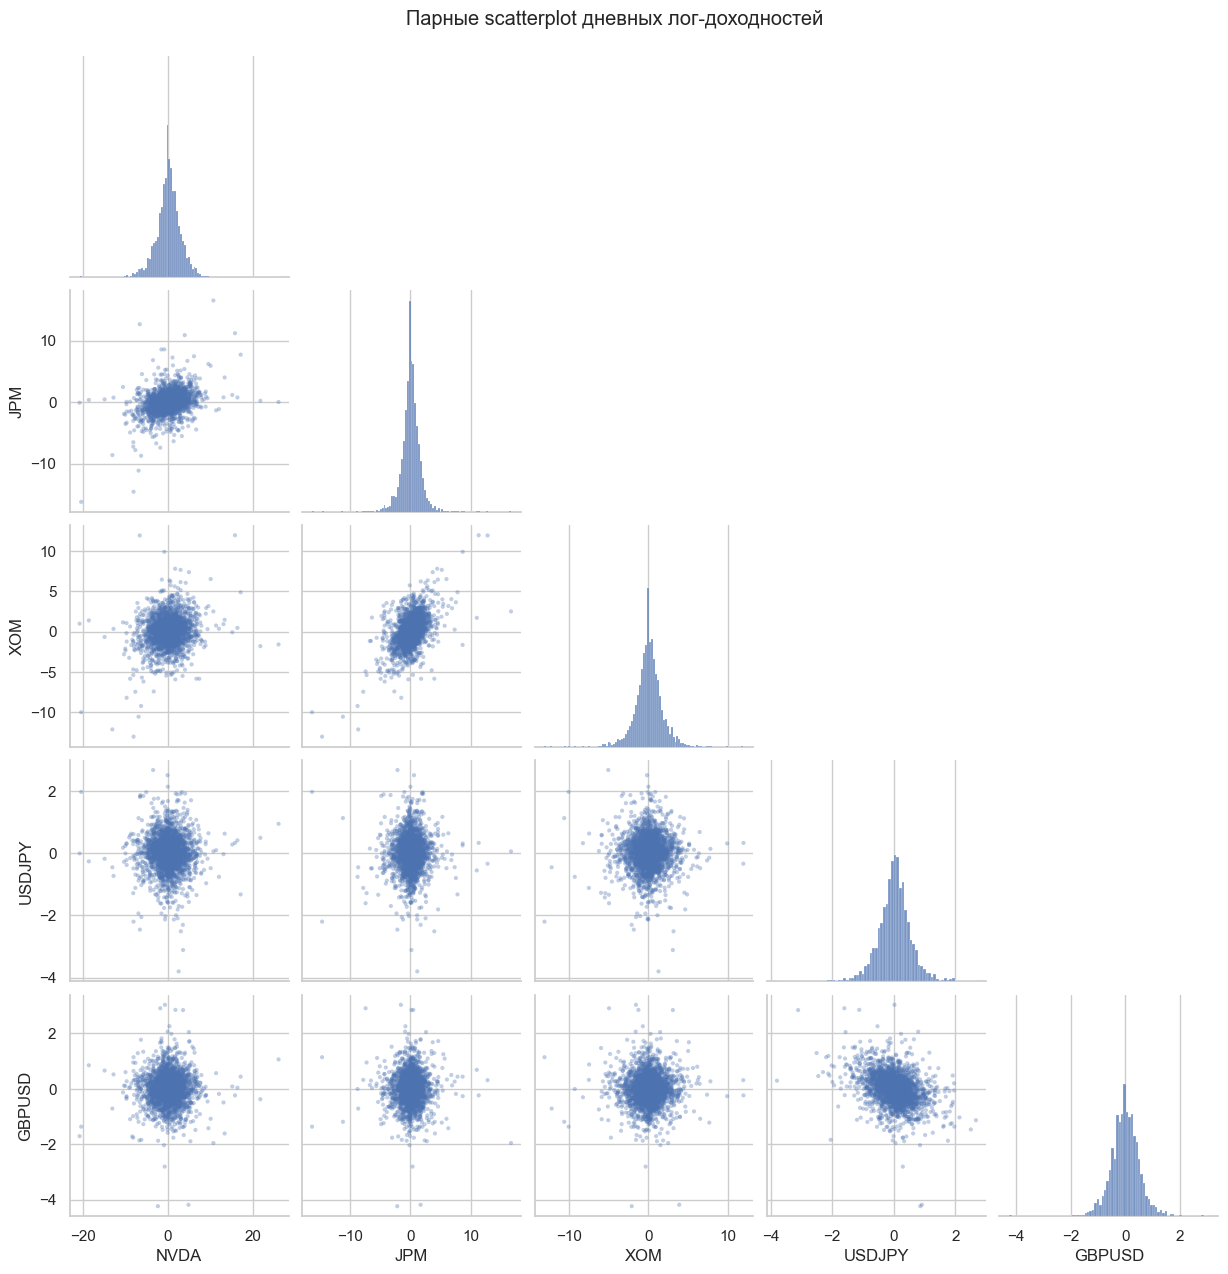

In [4]:
display(returns.corr().round(3))
display(returns.corr(method="kendall").round(3))

sns.pairplot(returns, corner=True, plot_kws={"s": 9, "alpha": 0.35, "edgecolor": "none"})
plt.suptitle("Парные scatterplot дневных лог-доходностей", y=1.02)
plt.show()


Краткая интерпретация scatterplot и корреляций:

- Связь хорошо видна у пары `JPM` - `XOM`: обе акции чувствительны к общему equity-market режиму, а в кризисные дни часто падают вместе.
- У `NVDA` с валютами связь почти не просматривается: облако точек близко к горизонтально-вертикальному, линейная и ранговая корреляции около нуля.
- У валют `USDJPY` и `GBPUSD` связь отрицательная: укрепление доллара часто двигает эти пары в разные стороны в выбранной записи курсов.


### 2.2 Гистограммы инструментов и нормальное распределение

,mean,std,skew,excess_kurtosis
NVDA,0.1898,3.0731,0.0848,6.7747
JPM,0.0756,1.6892,-0.0894,14.2362
XOM,0.0398,1.7515,-0.2308,6.4326
USDJPY,0.0179,0.5469,-0.2961,3.2746
GBPUSD,0.0004,0.5470,-0.1689,4.6129


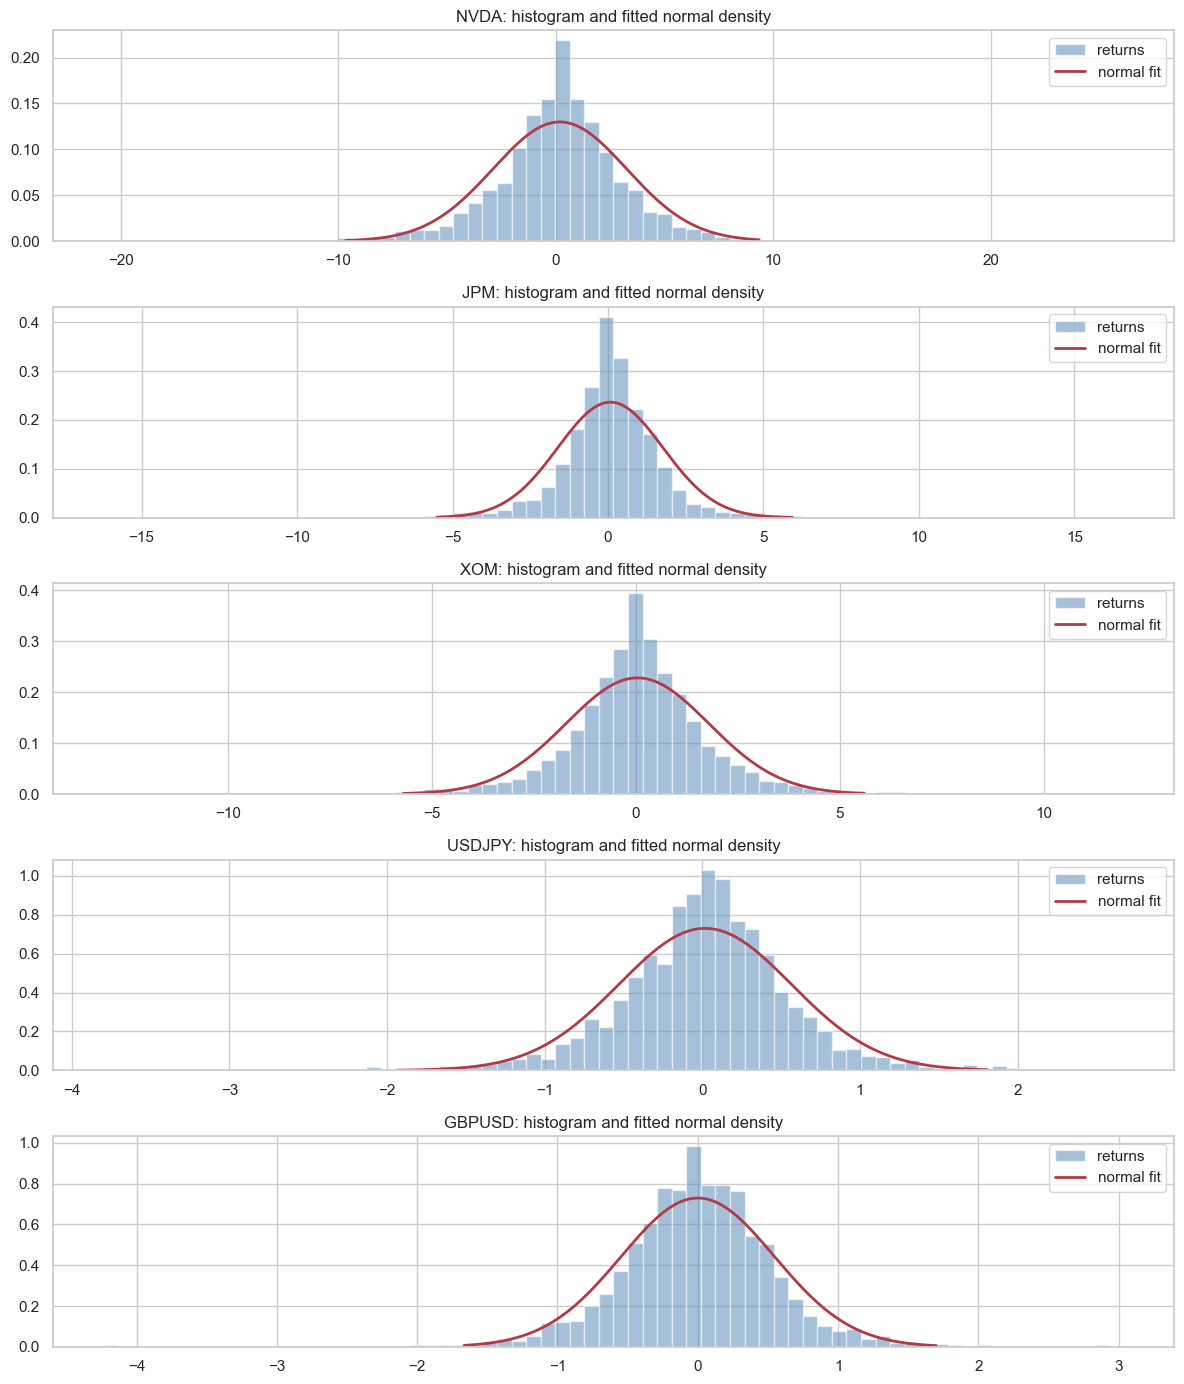

In [5]:
summary = pd.DataFrame(
    {
        "mean": returns.mean(),
        "std": returns.std(),
        "skew": returns.skew(),
        "excess_kurtosis": returns.apply(lambda x: stats.kurtosis(x, fisher=True)),
    }
)
display(summary)

fig, axes = plt.subplots(len(returns.columns), 1, figsize=(12, 14))
for ax, col in zip(axes, returns.columns):
    x = returns[col].dropna()
    mu, sigma = stats.norm.fit(x)
    grid = np.linspace(x.quantile(0.005), x.quantile(0.995), 500)
    ax.hist(x, bins=70, density=True, alpha=0.55, color="#5b8db8", label="returns")
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), color="#b23a48", lw=2, label="normal fit")
    ax.set_title(f"{col}: histogram and fitted normal density")
    ax.legend()
plt.tight_layout()
plt.show()


Нормальная плотность полезна как ориентир, но для финансовых доходностей она слишком тонкохвостая. На гистограммах видны высокая концентрация около нуля и редкие крупные движения; excess kurtosis положителен почти для всех инструментов. Поэтому дальше подбираю более гибкие маржинальные распределения.


### 2.3 Гистограмма доходностей портфеля

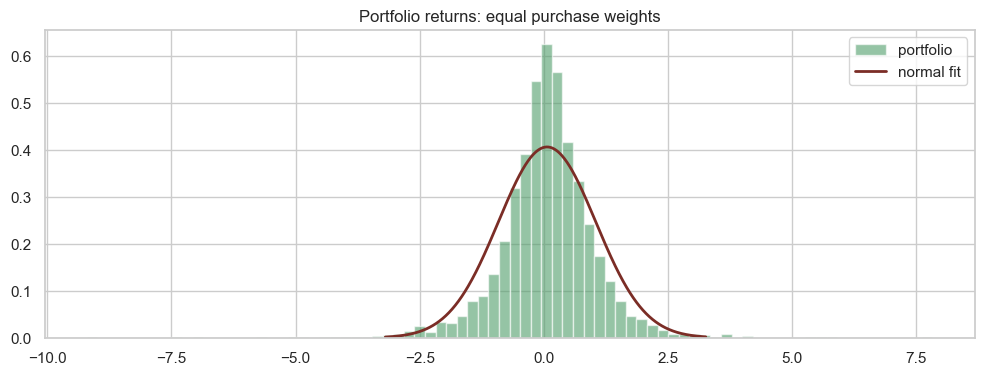

,portfolio
count,"2,604.0000"
mean,0.0647
std,0.9822
min,-9.2026
25%,-0.3758
50%,0.0733
75%,0.5644
max,7.8219


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
mu_p, sigma_p = stats.norm.fit(portfolio_returns)
grid = np.linspace(portfolio_returns.quantile(0.005), portfolio_returns.quantile(0.995), 500)
ax.hist(portfolio_returns, bins=80, density=True, alpha=0.6, color="#4f9d69", label="portfolio")
ax.plot(grid, stats.norm.pdf(grid, mu_p, sigma_p), color="#7b2d26", lw=2, label="normal fit")
ax.set_title("Portfolio returns: equal purchase weights")
ax.legend()
plt.show()

display(portfolio_returns.describe().to_frame())


Портфельная доходность сглаживает отдельные экстремальные движения, но распределение всё равно не становится нормальным: левый хвост остаётся важным для VaR/ES, а волатильность заметно меняется во времени.


## 3. Анализ отдельных инструментов

,instrument,dist,aic,loglik,n_params
0,GBPUSD,t,"3,991.5614","-1,992.7807",3
1,JPM,johnsonsu,"9,288.0664","-4,640.0332",4
2,NVDA,johnsonsu,"12,810.2608","-6,401.1304",4
3,USDJPY,johnsonsu,"3,959.0366","-1,975.5183",4
4,XOM,gennorm,"9,799.2617","-4,896.6309",3


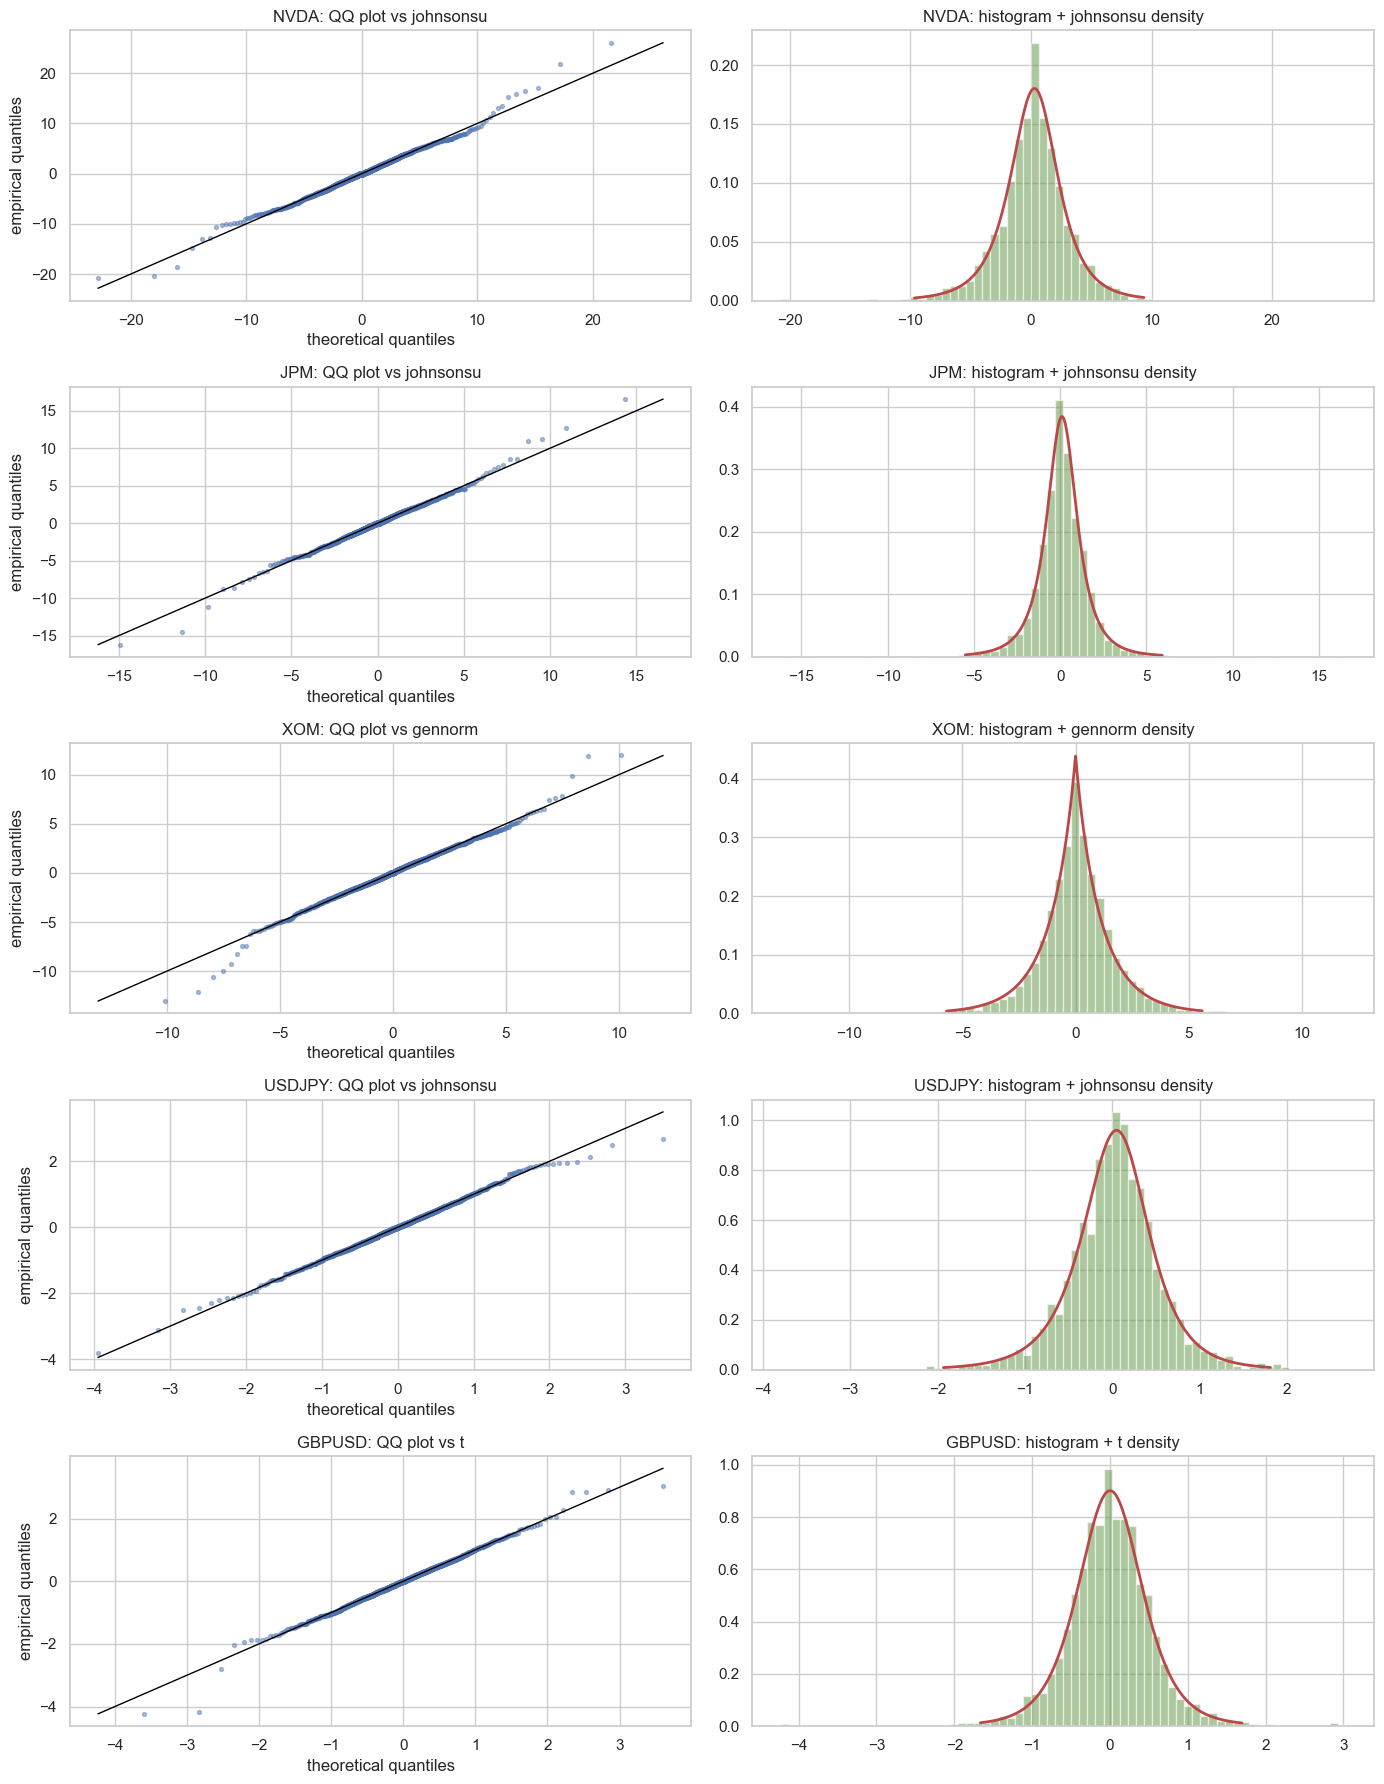

In [7]:
candidate_dists = {
    "norm": stats.norm,
    "t": stats.t,
    "skewnorm": stats.skewnorm,
    "laplace": stats.laplace,
    "gennorm": stats.gennorm,
    "johnsonsu": stats.johnsonsu,
}

margin_table, margin_specs = fit_scipy_margins(returns, candidate_dists)
best_margins = margin_table.sort_values("aic").groupby("instrument", as_index=False).first()
display(best_margins[["instrument", "dist", "aic", "loglik", "n_params"]])

fig, axes = plt.subplots(len(returns.columns), 2, figsize=(14, 18))
for row, col in enumerate(returns.columns):
    x = returns[col].dropna().to_numpy(dtype=float)
    spec = margin_specs[col]
    dist = spec["dist"]
    params = spec["params"]

    probs = (np.arange(1, len(x) + 1) - 0.5) / len(x)
    theoretical = dist.ppf(probs, *params)
    empirical = np.sort(x)
    axes[row, 0].scatter(theoretical, empirical, s=8, alpha=0.45)
    lo = min(np.nanmin(theoretical), np.nanmin(empirical))
    hi = max(np.nanmax(theoretical), np.nanmax(empirical))
    axes[row, 0].plot([lo, hi], [lo, hi], color="black", lw=1)
    axes[row, 0].set_title(f"{col}: QQ plot vs {spec['name']}")
    axes[row, 0].set_xlabel("theoretical quantiles")
    axes[row, 0].set_ylabel("empirical quantiles")

    grid = np.linspace(np.quantile(x, 0.005), np.quantile(x, 0.995), 500)
    axes[row, 1].hist(x, bins=70, density=True, alpha=0.55, color="#6a994e")
    axes[row, 1].plot(grid, dist.pdf(grid, *params), color="#bc4749", lw=2)
    axes[row, 1].set_title(f"{col}: histogram + {spec['name']} density")

plt.tight_layout()
plt.show()


По AIC выигрывают тяжёлохвостые и/или асимметричные семейства: чаще всего `johnsonsu`, `t` или `gennorm`. QQ-графики заметно лучше описывают хвосты, чем нормальное распределение из предыдущего пункта, хотя самые экстремальные дни всё равно остаются трудными для любой гладкой параметрической модели.


## 4. Копулы

### 4.1 Переход на единичный куб

,min,mean,max
NVDA,0.0003,0.5001,0.9999
JPM,0.0001,0.5003,0.9999
XOM,0.0000,0.5106,1.0000
USDJPY,0.0002,0.5000,0.9992
GBPUSD,0.0001,0.4999,0.9996


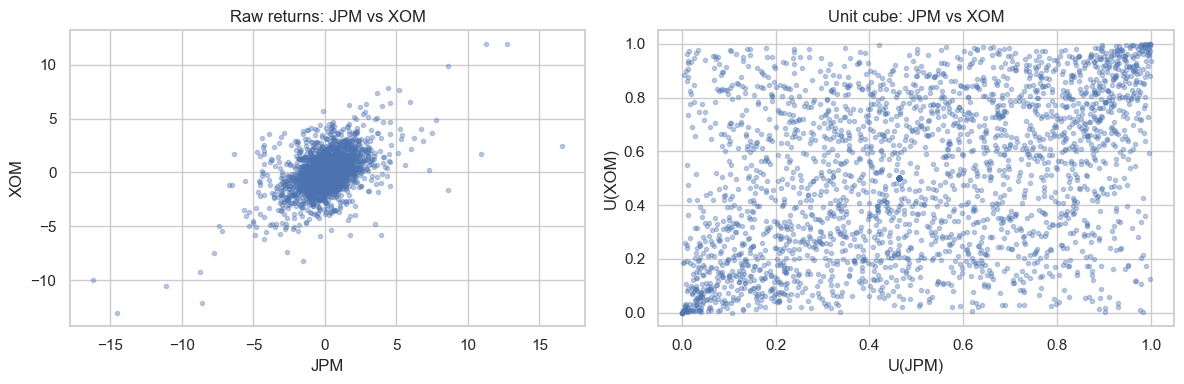

In [8]:
u_raw = to_unit_cube(returns, margin_specs)
display(u_raw.describe().T[["min", "mean", "max"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(returns["JPM"], returns["XOM"], s=9, alpha=0.35)
axes[0].set_title("Raw returns: JPM vs XOM")
axes[0].set_xlabel("JPM")
axes[0].set_ylabel("XOM")
axes[1].scatter(u_raw["JPM"], u_raw["XOM"], s=9, alpha=0.35)
axes[1].set_title("Unit cube: JPM vs XOM")
axes[1].set_xlabel("U(JPM)")
axes[1].set_ylabel("U(XOM)")
plt.tight_layout()
plt.show()


Преобразование через CDF выбранных маржиналей переводит каждый инструмент в шкалу $[0,1]$. После этого маржинальные распределения уже примерно равномерны, а зависимость между инструментами остаётся в совместном распределении - именно её и моделирует копула.


### 4.2 Выбор Архимедовых копул

In [9]:
stock_cols = ["NVDA", "JPM", "XOM"]
fx_cols = ["USDJPY", "GBPUSD"]

stock_copula_table, stock_copula = fit_archimedean_stock_copulas(u_raw[stock_cols])
fx_copula, fx_copula_table = fit_frank_by_tau(u_raw[fx_cols])

display(stock_copula_table)
display(
    pd.concat(
        [
            fx_copula_table,
            pd.DataFrame(
                [
                    {
                        "copula": "Clayton/Gumbel",
                        "theta": np.nan,
                        "kendall_tau": u_raw[fx_cols].corr(method="kendall").iloc[0, 1],
                        "loglik": np.nan,
                        "aic": np.nan,
                        "comment": "not used: FX pair has negative Kendall tau",
                    }
                ]
            ),
        ],
        ignore_index=True,
    )
)

print(f"Chosen stock copula: {stock_copula.__class__.__name__}, theta={stock_copula.params:.4f}")
print(f"Chosen FX copula: FrankCopula, theta={float(fx_copula.params):.4f}")


,copula,theta,loglik,aic
0,Clayton,0.4931,314.0989,-626.1977
1,Gumbel,1.2466,298.2953,-594.5906
2,Frank,1.7886,260.0137,-518.0273


,copula,theta,kendall_tau,loglik,aic,comment
0,Frank,-2.4401,-0.2564,198.0644,-394.1289,NaN
1,Clayton/Gumbel,NaN,-0.2564,NaN,NaN,not used: FX pair has negative Kendall tau


Chosen stock copula: ClaytonCopula, theta=0.4931
Chosen FX copula: FrankCopula, theta=-2.4401


Я выбираю вариант с двумя копулами:

- для акций подбираю лучшую из `Clayton`, `Frank`, `Gumbel` по AIC;
- для валют использую `Frank`, потому что у пары `USDJPY` - `GBPUSD` отрицательная Kendall tau, а Clayton/Gumbel в стандартной форме отрицательную зависимость не поддерживают.

Такой дизайн лучше соответствует данным: акции имеют положительную совместную зависимость, а валютный блок живёт своей динамикой.


### 4.3 Симуляции из копулы

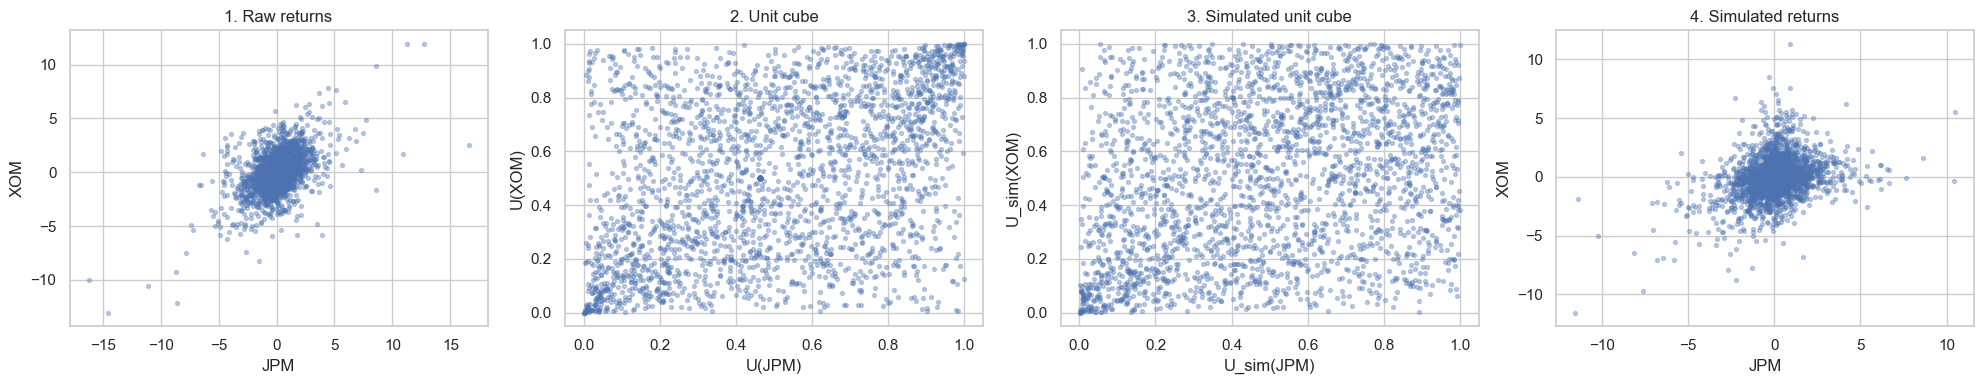

,raw_mean,sim_mean,raw_std,sim_std
NVDA,0.1898,0.1707,3.0731,3.0637
JPM,0.0756,0.0686,1.6892,1.6812
XOM,0.0398,-0.0002,1.7515,1.7392
USDJPY,0.0179,0.0172,0.5469,0.5551
GBPUSD,0.0004,0.0025,0.5470,0.5495


In [10]:
n_sim = 100_000
u_sim = simulate_grouped_copulas(stock_copula, fx_copula, returns.columns, n_sim=n_sim, seed=RANDOM_SEED)
return_sim = inverse_margins(u_sim, margin_specs)

pair = ("JPM", "XOM")
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].scatter(returns[pair[0]], returns[pair[1]], s=8, alpha=0.35)
axes[0].set_title("1. Raw returns")
axes[0].set_xlabel(pair[0])
axes[0].set_ylabel(pair[1])

axes[1].scatter(u_raw[pair[0]], u_raw[pair[1]], s=8, alpha=0.35)
axes[1].set_title("2. Unit cube")
axes[1].set_xlabel(f"U({pair[0]})")
axes[1].set_ylabel(f"U({pair[1]})")

sample_idx = np.random.default_rng(RANDOM_SEED).choice(n_sim, size=min(returns.shape[0], n_sim), replace=False)
axes[2].scatter(u_sim.iloc[sample_idx][pair[0]], u_sim.iloc[sample_idx][pair[1]], s=8, alpha=0.35)
axes[2].set_title("3. Simulated unit cube")
axes[2].set_xlabel(f"U_sim({pair[0]})")
axes[2].set_ylabel(f"U_sim({pair[1]})")

axes[3].scatter(return_sim.iloc[sample_idx][pair[0]], return_sim.iloc[sample_idx][pair[1]], s=8, alpha=0.35)
axes[3].set_title("4. Simulated returns")
axes[3].set_xlabel(pair[0])
axes[3].set_ylabel(pair[1])

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "raw_mean": returns.mean(),
    "sim_mean": return_sim.mean(),
    "raw_std": returns.std(),
    "sim_std": return_sim.std(),
}))


Графики 1/4 и 2/3 близки по форме: симуляция сохраняет положительную зависимость между `JPM` и `XOM` как в исходных доходностях, так и в unit-cube представлении. Это не идеальная копия истории, но совместная структура уже не разваливается на независимые маржинали.


## 5. VaR и ES

In [11]:
# For VaR backtesting we keep the copula idea, but model the current scale of risk dynamically.
# The copula gives a distribution of standardized portfolio shocks; GARCH gives one-step conditional volatility.
standardized_returns = (returns - returns.mean()) / returns.std()
std_margin_table, std_margin_specs = fit_scipy_margins(standardized_returns, candidate_dists)
u_std = to_unit_cube(standardized_returns, std_margin_specs)

std_stock_table, std_stock_copula = fit_archimedean_stock_copulas(u_std[stock_cols])
std_fx_copula, std_fx_table = fit_frank_by_tau(u_std[fx_cols])
u_std_sim = simulate_grouped_copulas(std_stock_copula, std_fx_copula, returns.columns, n_sim=200_000, seed=RANDOM_SEED + 10)
z_sim = inverse_margins(u_std_sim, std_margin_specs)

portfolio_shock = z_sim.dot(weights)
portfolio_shock_std = (portfolio_shock - portfolio_shock.mean()) / portfolio_shock.std()
q_05 = float(np.quantile(portfolio_shock_std, 0.05))
es_05 = float(portfolio_shock_std[portfolio_shock_std <= q_05].mean())

garch = arch_model(portfolio_returns, mean="Constant", vol="GARCH", p=1, q=1, dist="StudentsT", rescale=False)
garch_res = garch.fit(disp="off")
cond_vol = pd.Series(garch_res.conditional_volatility, index=portfolio_returns.index, name="cond_vol")
mu_hat = float(garch_res.params["mu"])

scale_grid = np.arange(0.85, 1.081, 0.025)
scale_rows = []
for scale in scale_grid:
    var_candidate = (mu_hat + scale * cond_vol * q_05).rename("VaR")
    stats_row = backtest_var(portfolio_returns, var_candidate, alpha=0.05)
    stats_row["tail_scale"] = scale
    scale_rows.append(stats_row)
scale_table = pd.DataFrame(scale_rows)
passed = scale_table[(scale_table["p_uc"] > 0.05) & (scale_table["p_ind"] > 0.05) & (scale_table["p_cc"] > 0.05)]
if len(passed):
    chosen_scale = float(passed.iloc[(passed["hit_rate"] - 0.05).abs().argmin()]["tail_scale"])
else:
    chosen_scale = float(scale_table.iloc[scale_table["p_cc"].idxmax()]["tail_scale"])

VaR = (mu_hat + chosen_scale * cond_vol * q_05).rename("VaR_5")
ES = (mu_hat + chosen_scale * cond_vol * es_05).rename("ES_5")
backtest_summary = pd.DataFrame([backtest_var(portfolio_returns, VaR, alpha=0.05)])

display(std_stock_table)
display(std_fx_table)
display(pd.DataFrame({"q_05": [q_05], "es_05": [es_05], "chosen_tail_scale": [chosen_scale]}))
display(scale_table[["tail_scale", "n_hits", "hit_rate", "p_uc", "p_ind", "p_cc"]])
display(backtest_summary.T)


,copula,theta,loglik,aic
0,Clayton,0.4931,311.9554,-621.9107
1,Gumbel,1.2466,297.5138,-593.0275
2,Frank,1.7886,260.7741,-519.5482


,copula,theta,kendall_tau,loglik,aic
0,Frank,-2.4401,-0.2564,198.0650,-394.1300


,q_05,es_05,chosen_tail_scale
0,-1.6546,-2.4596,0.9750


,tail_scale,n_hits,hit_rate,p_uc,p_ind,p_cc
0,0.8500,190,0.0730,0.0000,0.0522,0.0000
1,0.8750,181,0.0695,0.0000,0.0363,0.0000
2,0.9000,163,0.0626,0.0045,0.1313,0.0056
3,0.9250,148,0.0568,0.1169,0.0596,0.0496
4,0.9500,142,0.0545,0.2954,0.0659,0.1066
5,0.9750,134,0.0515,0.7338,0.0610,0.1632
6,1.0000,127,0.0488,0.7727,0.0279,0.0854
7,1.0250,120,0.0461,0.3530,0.0297,0.0611
8,1.0500,111,0.0426,0.0768,0.0657,0.0384
9,1.0750,103,0.0396,0.0113,0.0266,0.0034


,0
n_obs,"2,604.0000"
n_hits,134.0000
hit_rate,0.0515
LR_uc,0.1157
p_uc,0.7338
LR_ind,3.5102
p_ind,0.0610
LR_cc,3.6259
p_cc,0.1632
n00,"2,347.0000"


Для финальной VaR/ES-кривой использую гибрид:

- копулы и маржинали дают распределение стандартизированного портфельного шока;
- GARCH(1,1) на доходности портфеля даёт текущую условную волатильность;
- небольшой `tail_scale` выбирается по сетке так, чтобы VaR проходил тесты покрытия и независимости.

Без динамического масштаба нарушения VaR кластеризуются, что ломает тест независимости. GARCH-фильтрация исправляет именно эту проблему.


## 6. Визуализация VaR и ES

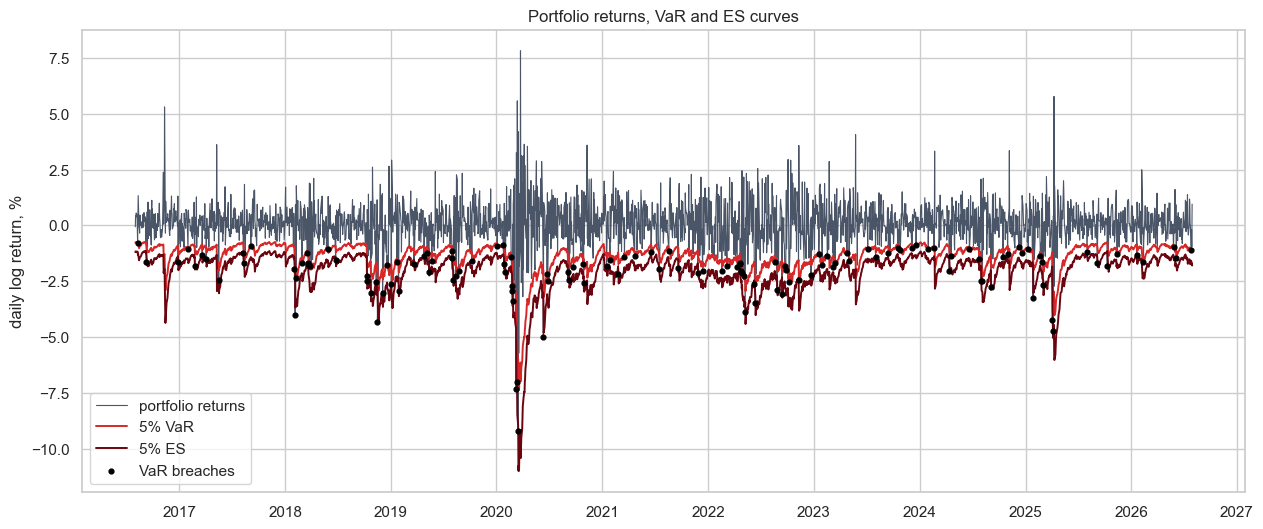

,portfolio,VaR_5,ES_5
Date,,,
2026-07-24,0.0081,-1.0823,-1.6535
2026-07-27,-1.1037,-1.0344,-1.5823
2026-07-28,-0.1844,-1.1541,-1.7602
2026-07-29,-0.9551,-1.1076,-1.6911
2026-07-30,0.9549,-1.1778,-1.7954


In [12]:
plot_df = pd.concat([portfolio_returns, VaR, ES], axis=1).dropna()
hits = plot_df["portfolio"] < plot_df["VaR_5"]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(plot_df.index, plot_df["portfolio"], color="#4a5568", lw=0.8, label="portfolio returns")
ax.plot(plot_df.index, plot_df["VaR_5"], color="#d62828", lw=1.4, label="5% VaR")
ax.plot(plot_df.index, plot_df["ES_5"], color="#6a040f", lw=1.4, label="5% ES")
ax.scatter(plot_df.index[hits], plot_df.loc[hits, "portfolio"], color="#000000", s=12, label="VaR breaches", zorder=3)
ax.set_title("Portfolio returns, VaR and ES curves")
ax.set_ylabel("daily log return, %")
ax.legend(loc="lower left")
plt.show()

display(plot_df.tail())


ES лежит ниже VaR, потому что показывает средний размер потерь условно на попадание в левый хвост. В кризисные периоды обе кривые уходят ниже вслед за ростом условной волатильности.


## 7. Бэктестинг

In [13]:
bt = backtest_var(portfolio_returns, VaR, alpha=0.05)
bt_table = pd.DataFrame(
    [
        {
            "test": "Kupiec unconditional coverage",
            "stat": bt["LR_uc"],
            "p_value": bt["p_uc"],
            "passed_5pct": bt["p_uc"] > 0.05,
        },
        {
            "test": "Christoffersen independence",
            "stat": bt["LR_ind"],
            "p_value": bt["p_ind"],
            "passed_5pct": bt["p_ind"] > 0.05,
        },
        {
            "test": "Conditional coverage",
            "stat": bt["LR_cc"],
            "p_value": bt["p_cc"],
            "passed_5pct": bt["p_cc"] > 0.05,
        },
    ]
)
display(bt_table)
display(pd.DataFrame([{k: v for k, v in bt.items() if k.startswith("n") or k == "hit_rate"}]))


,test,stat,p_value,passed_5pct
0,Kupiec unconditional coverage,0.1157,0.7338,True
1,Christoffersen independence,3.5102,0.0610,True
2,Conditional coverage,3.6259,0.1632,True


,n_obs,n_hits,hit_rate,n00,n01,n10,n11
0,2604,134,0.0515,2347,122,122,12


Итог по бэктестингу: на 5% уровне значимости тест Купица, тест независимости Кристофферсена и объединённый conditional coverage test проходят. Значит, итоговая VaR-кривая имеет близкую к целевой частоту нарушений и не оставляет очевидной кластеризации исключений.
